In [ ]:
#imports
import numpy as np
import time
import statistics
import matplotlib.pyplot as plt

In [ ]:
#configuration
np.random.seed(42)
VECTOR_SIZES = [10,50,100,200,500]
MATRIX_SIZES = [10,50,100,200,500]
TRIALS = 10

In [ ]:
def python_vector_multiply(a,b):
  result = [0.0] * len(a)
  for i in range(len(a)):
    result[i] = a[i] * b[i]
  return result

In [ ]:
def python_matrix_multiply(A,B):
  n = len(A)
  result = [[0.0] * n for _ in range(n)]
  for i in range(n):
    for j in range(n):
      sum_ij = 0.0
      for k in range(n):
        sum_ij += A[i][k] * B[k][j]
      result[i][j] = sum_ij
  return result

In [ ]:
def measure_time(func,*args):
  times = []

  #warmup
  func(*args)

  for _ in range(TRIALS):
    start = time.perf_counter()
    func(*args)
    end = time.perf_counter()
    times.append(end-start)

  return statistics.median(times)

In [ ]:
#vector tests
python_vector_times = []
numpy_vector_times = []

for size in VECTOR_SIZES:
  a = np.random.rand(size).astype(np.float64)
  b = np.random.rand(size).astype(np.float64)

  #convert to list for Python version
  a_list = a.tolist()
  b_list = b.tolist()

  #numpy timing
  t_numpy = measure_time(lambda x,y: x*y, a, b)
  numpy_vector_times.append(t_numpy)

  #python timing
  t_python = measure_time(python_vector_multiply, a_list, b_list)
  python_vector_times.append(t_python)


  #check
  python_result = python_vector_multiply(a_list, b_list)
  numpy_result = a*b

  assert np.allclose(python_result, numpy_result), "Vectors do not match!"

print("\nVECTOR MULTIPLICATION TIMES (median seconds)")
for size, p, n in zip(VECTOR_SIZES, python_vector_times, numpy_vector_times):
    print(f"Size {size}: Python = {p:.6f}, NumPy = {n:.6f}, Speedup = {p/n:.2f}x")


VECTOR MULTIPLICATION TIMES (median seconds)
Size 10: Python = 0.000002, NumPy = 0.000002, Speedup = 1.06x
Size 50: Python = 0.000005, NumPy = 0.000002, Speedup = 3.17x
Size 100: Python = 0.000010, NumPy = 0.000002, Speedup = 5.98x
Size 200: Python = 0.000020, NumPy = 0.000002, Speedup = 10.86x
Size 500: Python = 0.000052, NumPy = 0.000002, Speedup = 27.91x


In [ ]:
#matrix tests
python_matrix_times = []
numpy_matrix_times = []

for size in MATRIX_SIZES:
  A = np.random.rand(size, size).astype(np.float64)
  B = np.random.rand(size, size).astype(np.float64)

  A_list = A.tolist()
  B_list = B.tolist()

  t_numpy = measure_time(lambda x,y: x@y, A, B)
  numpy_matrix_times.append(t_numpy)

  t_python = measure_time(python_matrix_multiply, A_list, B_list)
  python_matrix_times.append(t_python)

  #check
  python_result = np.array(python_matrix_multiply(A_list, B_list))
  numpy_result = A @ B

  assert np.allclose(python_result, numpy_result), "Matrix results do not match!"

print("\nMATRIX MULTIPLICATION TIMES (median seconds)")
for size, p, n in zip(MATRIX_SIZES, python_matrix_times, numpy_matrix_times):
  print(f"Size {size}x{size}: Python = {p:.6f}, NumPy = {n:.6f}, Speedup = {p/n:.2f}x")



MATRIX MULTIPLICATION TIMES (median seconds)
Size 10x10: Python = 0.000095, NumPy = 0.000003, Speedup = 37.84x
Size 50x50: Python = 0.014439, NumPy = 0.000027, Speedup = 536.19x
Size 100x100: Python = 0.121061, NumPy = 0.000089, Speedup = 1365.84x
Size 200x200: Python = 0.749791, NumPy = 0.010494, Speedup = 71.45x
Size 500x500: Python = 17.130587, NumPy = 0.008353, Speedup = 2050.89x


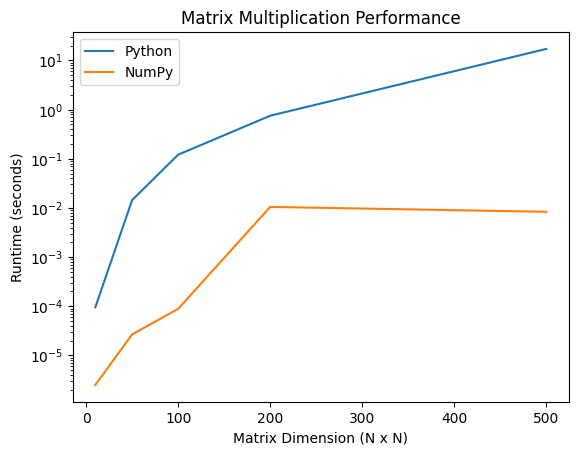

In [ ]:
#visualizing results
plt.figure()
plt.plot(MATRIX_SIZES, python_matrix_times, label="Python")
plt.plot(MATRIX_SIZES, numpy_matrix_times, label="NumPy")
plt.xlabel("Matrix Dimension (N x N)")
plt.ylabel("Runtime (seconds)")
plt.title("Matrix Multiplication Performance")
plt.yscale("log")
plt.legend()
plt.show()